In [1]:
adc_filename = "Test_2025-08-25-19-26-54\\raw_data.bin" 

# Parsing ADC Raw IQ Data Received via LVDS

## Parsing ADC Raw IQ Data Received via LVDS Using numpy

### Load relevant libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

### Set corresponding parameters

In [3]:
# You can fill in the parameters according to the cfg file (the terminal will also print them when running the acquisition program)
# ADC_PARAMS={'chirps': 128, 'rx': 4, 'tx': 3, 'samples': 256, 'IQ': 2, 'bytes': 2, 'startFreq': 76, 'idleTime': 7.0, 'adc_valid_start_time': 4.0, 'rampEndTime': 15.53, 'freq_slope': 265, 'txStartTime': 1.0, 'sample_rate': 22500, 'frame_periodicity': 8.952}

# You can also automatically read parameters from the cfg file
from mmwave.dataloader import DCA1000
_, _, ADC_PARAMS, _ = DCA1000.AWR2243_read_config("configFiles/AWR2243_mmwaveconfig.txt")
print(ADC_PARAMS)

{'chirps': 128, 'rx': 4, 'tx': 1, 'samples': 256, 'IQ': 2, 'bytes': 2, 'startFreq': 77.00025880336761, 'idleTime': 100.0, 'adc_valid_start_time': 6.0, 'rampEndTime': 60.0, 'freq_slope': 29.98173236846924, 'txStartTime': 0.0, 'sample_rate': 10000, 'frame_periodicity': 70.0}


### Load and parse the saved bin data

In [5]:
adc_data = np.fromfile(adc_filename, dtype=np.int16)


adc_data=np.reshape(adc_data,(-1,ADC_PARAMS['chirps'],ADC_PARAMS['tx'],ADC_PARAMS['samples'],ADC_PARAMS['IQ'],ADC_PARAMS['rx']))
print(adc_data.shape)

adc_data=np.transpose(adc_data,(0,1,2,5,3,4))

#Frames*Chirps*TX*RX(Lanes)*Samples*IQ
print(adc_data.shape)


adc_data = (1j * adc_data[...,1] + adc_data[...,0]).astype(np.complex64) 
#Frames*Chirps*TX*RX*Samples
print(adc_data.shape)

(8, 128, 1, 256, 2, 4)
(8, 128, 1, 4, 256, 2)
(8, 128, 1, 4, 256)


### Graph time-domain IQ waveform

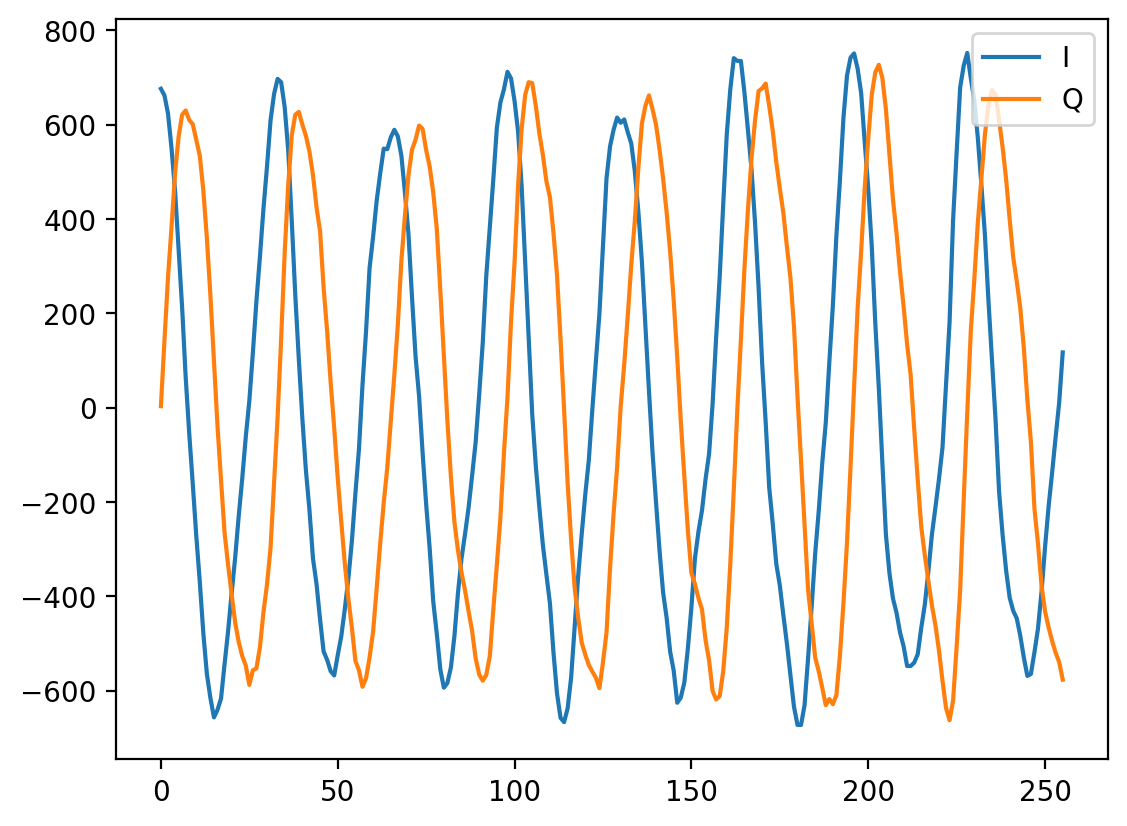

In [ ]:
frame_index = 5 # You can change this to visualize different frames
plt.plot(np.real(adc_data[frame_index,0,0,0,:]),label="I") # I
plt.plot(np.imag(adc_data[frame_index,0,0,0,:]),label="Q") # Q
plt.legend()
plt.show()

### Range-FFT

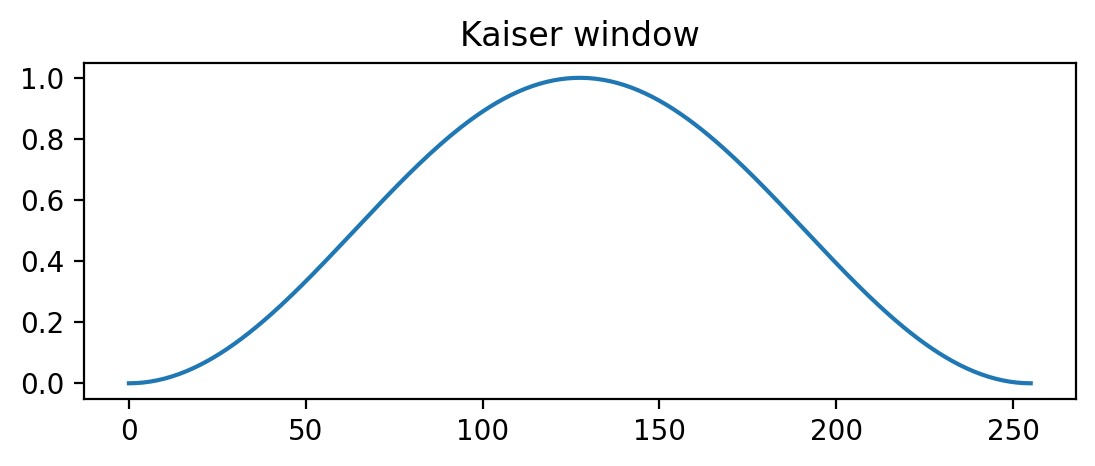

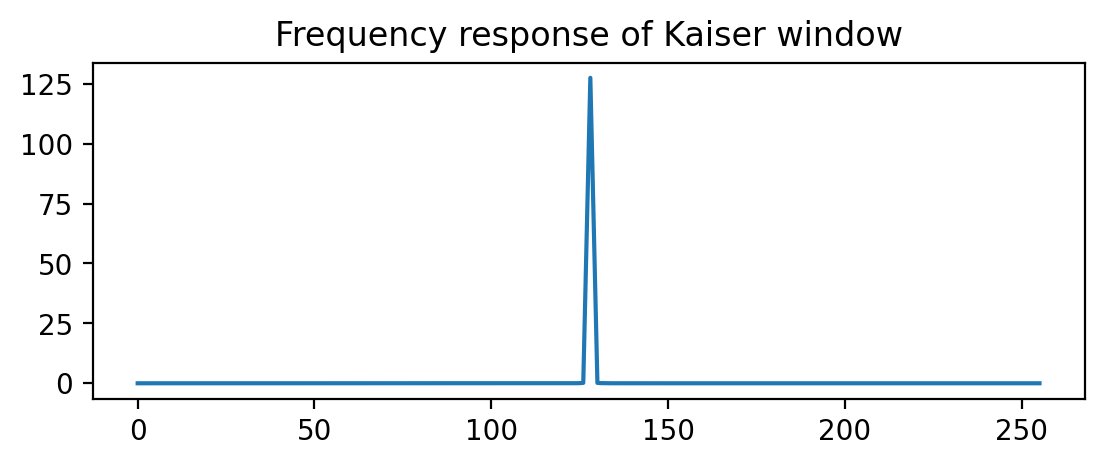

In [7]:
# window=np.kaiser(ADC_PARAMS['samples'], 4)
window=np.hanning(ADC_PARAMS['samples'])
window_fft = np.fft.fft(window, ADC_PARAMS['samples'])
window_fft = np.fft.fftshift(window_fft)

plt.subplot(2,1,1)
plt.plot(window)
plt.title("Kaiser window")
plt.show()

plt.subplot(2,1,2)
plt.plot(np.abs(window_fft))
plt.title("Frequency response of Kaiser window")
plt.show()



# window=np.tile(window,(adc_data.shape[0],adc_data.shape[1],adc_data.shape[2],adc_data.shape[3],1))

In [28]:
adc_data_w=adc_data*window

Range Resolution: 0.19543150235581797 [meters]


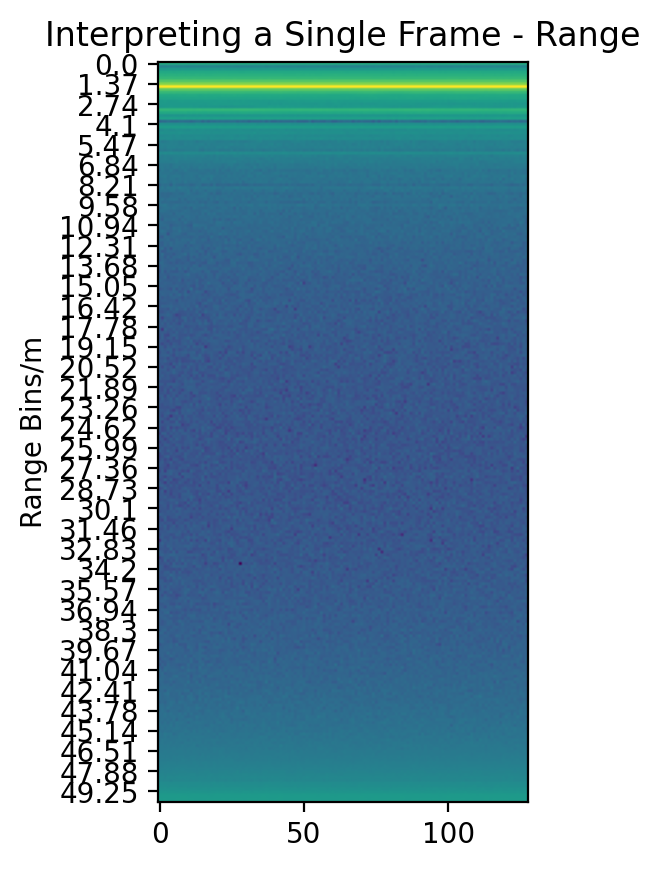

In [8]:
range_plot = np.fft.fft(adc_data[frame_index], axis=-1)
# Calculating bandwidth of the chirp, accounting for unit conversion
chirp_bandwidth = (ADC_PARAMS['freq_slope'] * 1e12 * ADC_PARAMS['samples']) / (ADC_PARAMS['sample_rate'] * 1e3)

# Using our derived equation for range resolution
range_res = 3e8 / (2 * chirp_bandwidth)
print(f'Range Resolution: {range_res} [meters]')

# Apply the range resolution factor to the range indices
ranges = np.round(np.arange(ADC_PARAMS['samples']) * range_res,2)

# Visualize Results
plt.imshow(np.log(np.abs(range_plot[:,0,:,:].sum(1)).T))
plt.ylabel('Range Bins/m')
plt.yticks(np.arange(ADC_PARAMS['samples'])[::7],ranges[::7])
plt.title('Interpreting a Single Frame - Range')
plt.show()

### Doppler-FFT

In [9]:
window_d=np.kaiser(ADC_PARAMS['chirps'], 2)
range_plot_w=(range_plot.T*window_d).T

Velocity Resolution: 0.09511940432179009 [meters/sec]
Max Velocity: 6.0876418765945655 [meters/sec]


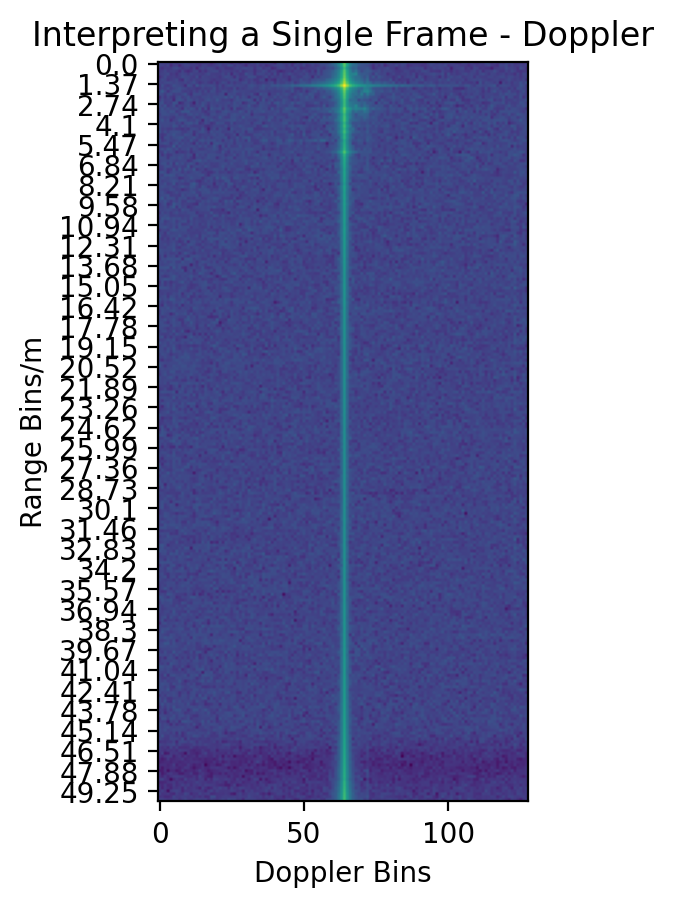

In [10]:
range_doppler = np.fft.fft(range_plot_w, axis=0)
range_doppler = np.fft.fftshift(range_doppler, axes=0)


StartWaveLenght = (3e8 / (ADC_PARAMS['startFreq'] * 1e9))
TimeChirp = 1e-6 *(ADC_PARAMS['idleTime'] + ADC_PARAMS['rampEndTime'])
TimeFrame = TimeChirp * ADC_PARAMS['chirps']
VelocityRes = (StartWaveLenght) / (2 * (TimeFrame))
print(f'Velocity Resolution: {VelocityRes} [meters/sec]')
MaxVelocity = StartWaveLenght / (4 * TimeChirp)
print(f'Max Velocity: {MaxVelocity} [meters/sec]')
# Visualize Results
plt.imshow(np.log(np.abs(range_doppler[:,0,:,:]).T).sum(1))
plt.xlabel('Doppler Bins')
plt.ylabel('Range Bins/m')
plt.yticks(np.arange(ADC_PARAMS['samples'])[::7],ranges[::7])
plt.title('Interpreting a Single Frame - Doppler')
plt.show()

### Azimuth-FFT

In [12]:
# Convert rectangular image to circular (fan-shaped)
def fanScan(im, r0=0, angle=180, k=7, top=True):
    """
    Convert a rectangular image to a circular (fan-shaped) image.
    im          - Input 2D image
    angle       - Fan angle in degrees
    r0          - Inner circle radius; r0=0 outputs a sector
    k           - Interpolation density for neighboring points (increase k if white noise appears in the image)
    top         - Center of the circle at the top
    """
    h, w = im.shape  # Height and width of the input image

    if r0 > 0:  # If output is a ring, add background to the top of the image
        bg = np.zeros((r0, w))
        im = np.append(bg, im, axis=0) if top else np.append(im, bg, axis=0)

    h, w = im.shape  # Height and width after adding background
    r = 2 * h - 1    # Output image height and width
    im_fan = np.zeros((r, r))  # Create output image as a numpy array

    idx = np.arange(h) if top else np.arange(h)[::-1]
    alpha = np.radians(np.linspace(-angle / 2, angle / 2, k * w))  # Generate fan angle sequence
    for i in range(k * w):  # Iterate over each column of the input image
        rows = np.int32(np.ceil(np.cos(alpha[i]) * idx)) + r // 2
        cols = np.int32(np.ceil(np.sin(alpha[i]) * idx)) + r // 2
        im_fan[(rows, cols)] = im[:, i // k]

    if 360 > angle >= 180:  # Crop the blank area at the top of the output image
        im_fan = im_fan[int(h * (1 - np.sin(np.radians((angle / 2 - 90))))):]

    if not top:
        im_fan = im_fan[::-1]
    return im_fan

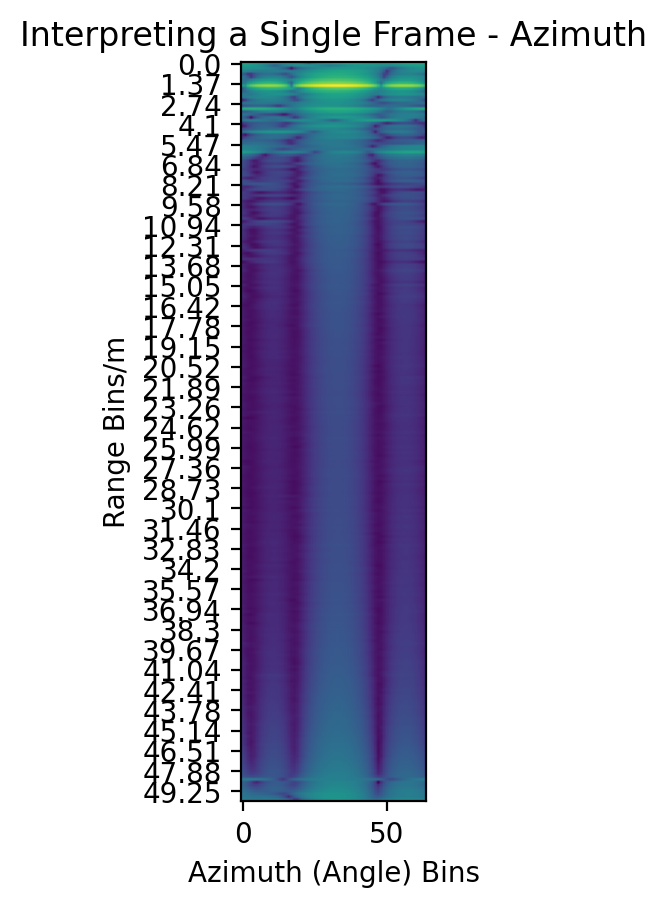

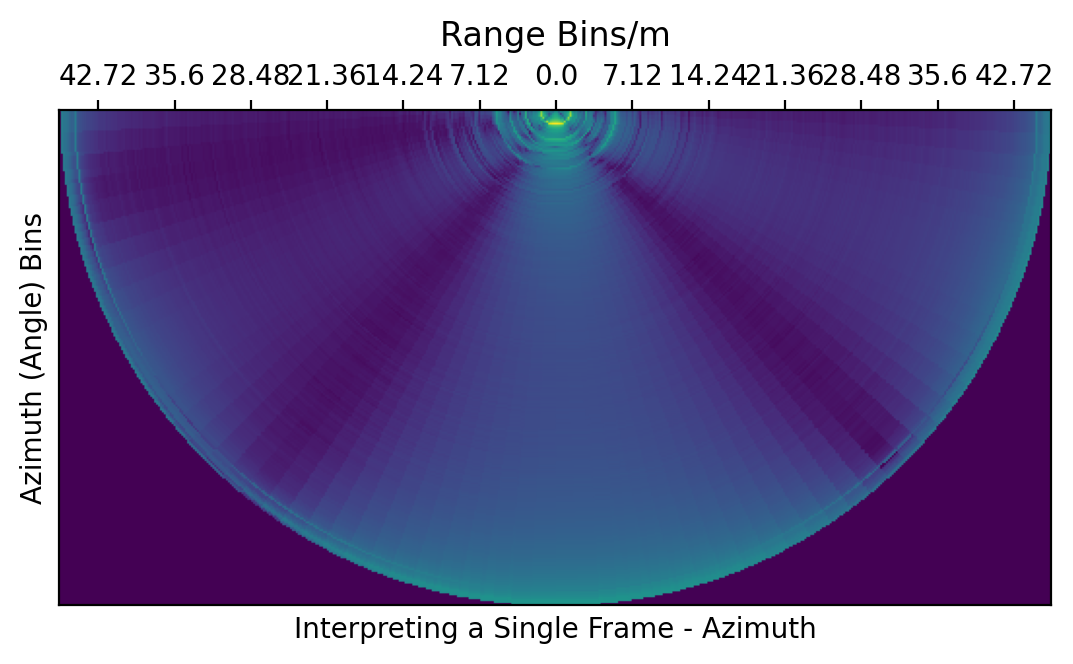

In [13]:
num_angle_bins = 64

# Prepare azimuth data (take first 2 RX channels, reshape for FFT)
range_azimuth = range_plot_w[:, :2, :, :].reshape((ADC_PARAMS['chirps'], -1, ADC_PARAMS['samples']))
range_azimuth = np.fft.fft(range_azimuth, num_angle_bins, axis=1)
range_azimuth = np.fft.fftshift(range_azimuth, axes=1)

# Plot planar image
range_azimuth_img = np.log(np.abs(range_azimuth).sum(0).T)
range_azimuth_img = range_azimuth_img - np.min(range_azimuth_img)
range_azimuth_img = range_azimuth_img / np.max(range_azimuth_img)
plt.imshow(range_azimuth_img)
plt.xlabel('Azimuth (Angle) Bins')
plt.ylabel('Range Bins/m')
plt.yticks(np.arange(ADC_PARAMS['samples'])[::7], ranges[::7])
plt.title('Interpreting a Single Frame - Azimuth')
plt.show()

# Plot fan-shaped image
im_fan = fanScan(range_azimuth_img, r0=0, angle=180, k=50, top=True)
plt.imshow(im_fan)

# Move coordinate labels to the top
ax = plt.gca()
ax.xaxis.set_ticks_position('top')

# Annotate range
labelNum = 7  # Number of labels per side
range_xlabel = np.arange(0, ranges[-1], ranges[-1] / labelNum)
range_xlabel = np.round(np.concatenate((range_xlabel[:0:-1], range_xlabel)), 2)
range_xticks_l = np.arange((ADC_PARAMS['samples'] * 2 - 1) / 2, 0, -(ADC_PARAMS['samples'] * 2 - 1) / (2 * labelNum - 1))
range_xticks_h = np.arange((ADC_PARAMS['samples'] * 2 - 1) / 2, ADC_PARAMS['samples'] * 2 - 1, (ADC_PARAMS['samples'] * 2 - 1) / (2 * labelNum - 1))
range_xticks = np.concatenate((range_xticks_l[:0:-1], range_xticks_h))
plt.xticks(range_xticks, range_xlabel)

plt.yticks([])  # Remove y-axis ticks
plt.title('Range Bins/m')
plt.ylabel('Azimuth (Angle) Bins')
plt.xlabel('Interpreting a Single Frame - Azimuth')
plt.show()